In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

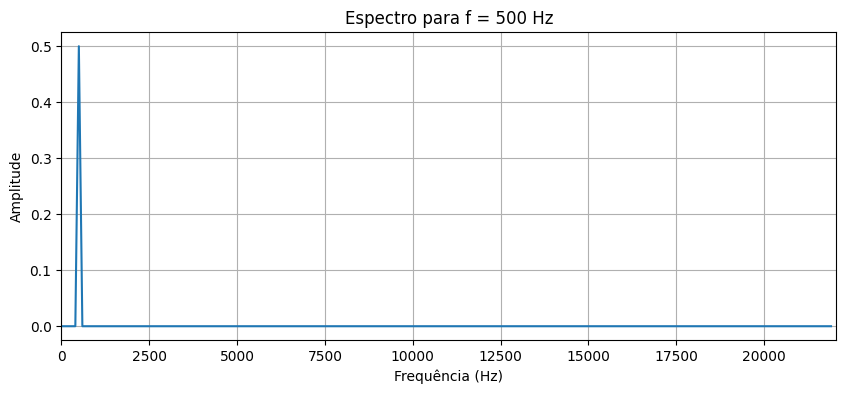

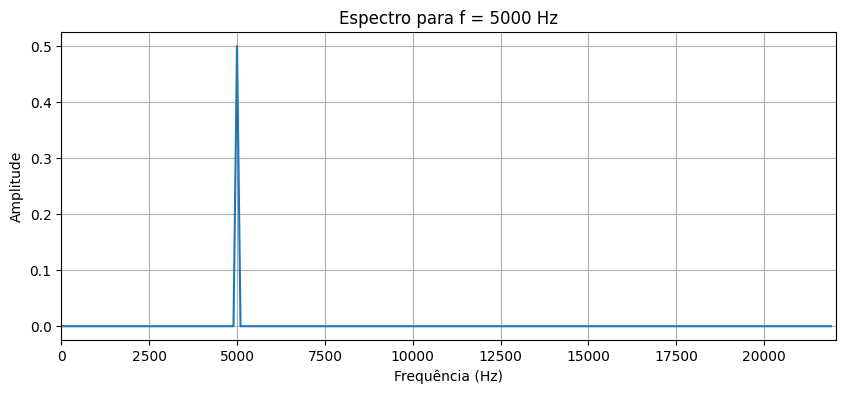

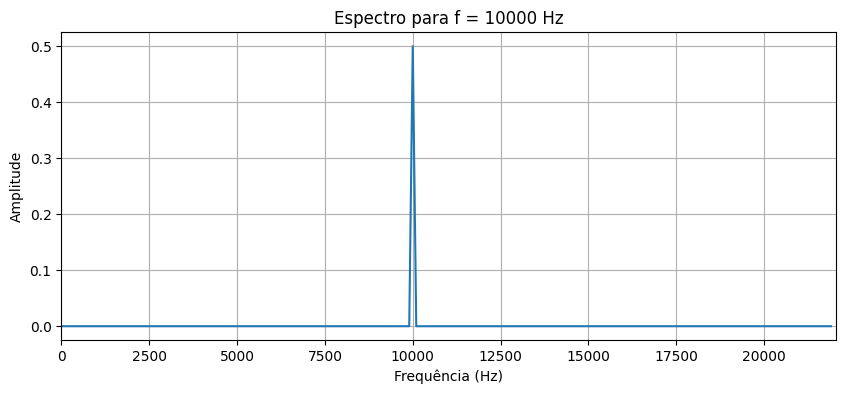

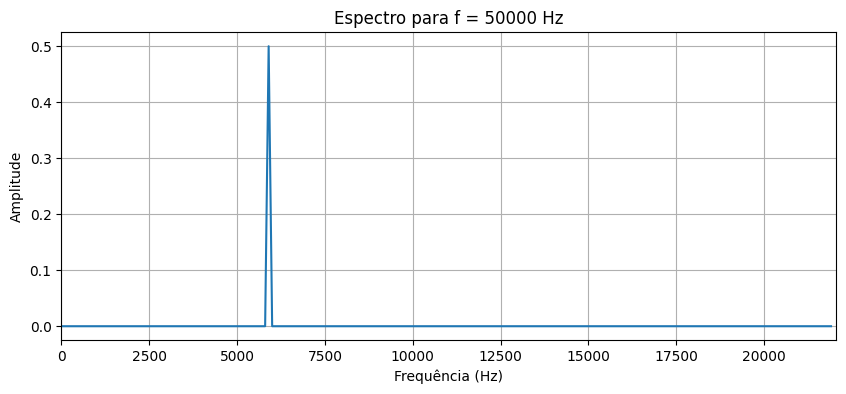

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Função do espectro (igual a sua)
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency

    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


# Parâmetros
fs = 44100  # Hz
duration = 0.01  # segundos
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

frequencies_to_test = [500, 5000, 10000, 50000]

# Loop para testar cada frequência
for f in frequencies_to_test:
    x = np.cos(2 * np.pi * f * t)

    freq, amp = calculate_spectrum(x, fs, single_sided=True)

    plt.figure(figsize=(10, 4))
    plt.plot(freq, amp)
    plt.title(f'Espectro para f = {f} Hz')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, fs/2)
    plt.grid(True)
    plt.show()

In [ ]:
#B)
#Para frequências abaixo da frequência de Nyquist (22050 Hz), o espectro apresenta picos exatamente nas frequências esperadas (500 Hz, 5000 Hz e 10000 Hz).
#Para a frequência de 50000 Hz, ocorre aliasing, pois ela excede a frequência de Nyquist.
#Como resultado, o sinal é interpretado como uma frequência mais baixa (aproximadamente 5900 Hz), aparecendo deslocado no espectro.
#Isso demonstra a importância do critério de Nyquist na amostragem de sinais.

In [ ]:
#exercício 2

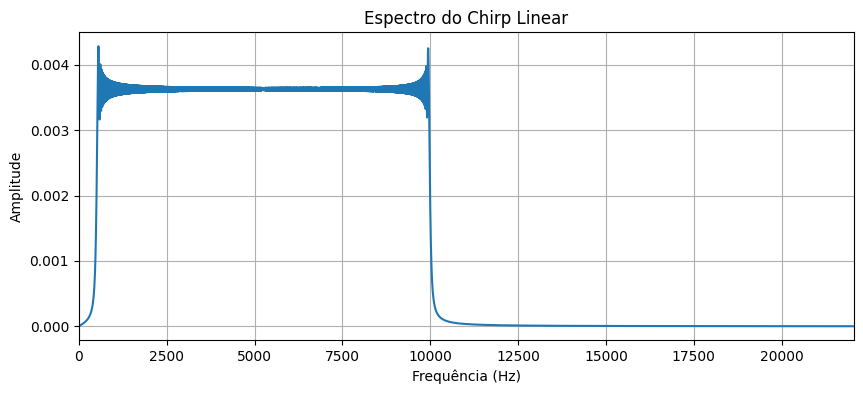

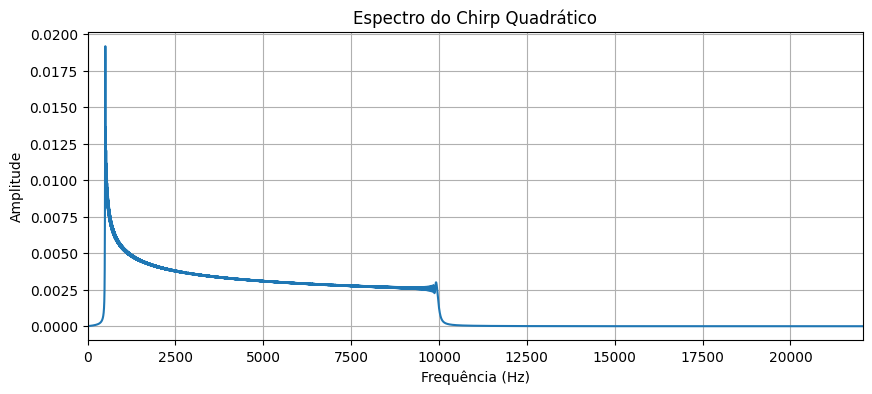

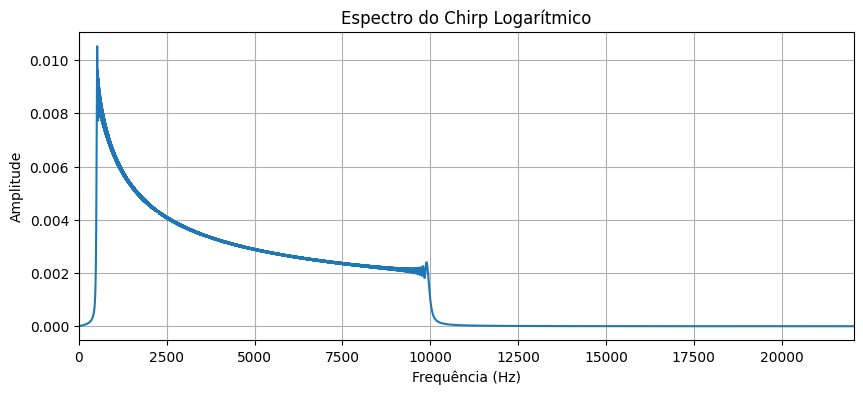

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import chirp

# Função do espectro (mesma da questão anterior)
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


# Parâmetros
fs = 44100
duration = 2
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

f0 = 500
f1 = 10000

# Tipos de chirp
chirps = {
    "Linear": chirp(t, f0=f0, f1=f1, t1=duration, method='linear'),
    "Quadrático": chirp(t, f0=f0, f1=f1, t1=duration, method='quadratic'),
    "Logarítmico": chirp(t, f0=f0, f1=f1, t1=duration, method='logarithmic')
}

# Plot dos espectros
for name, signal in chirps.items():
    freq, amp = calculate_spectrum(signal, fs)

    plt.figure(figsize=(10, 4))
    plt.plot(freq, amp)
    plt.title(f'Espectro do Chirp {name}')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, fs/2)
    plt.grid(True)
    plt.show()

In [ ]:
#B)
#O espectro dos sinais chirp apresenta energia distribuída ao longo de uma faixa de frequências, ao invés de picos discretos como no caso de senoides puras.
#Para o chirp linear, a energia é aproximadamente uniforme entre 500 Hz e 10000 Hz.
#Para o chirp quadrático, a distribuição de energia não é uniforme, refletindo a variação não linear da frequência ao longo do tempo.
#Para o chirp logarítmico, observa-se uma concentração maior de energia em determinadas regiões do espectro, devido ao crescimento exponencial da frequência.
#Esses resultados mostram que sinais com frequência variável possuem espectros mais espalhados, cobrindo toda a faixa de frequências percorrida.

In [ ]:
#Exercicio 3

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from google.colab import files

print("Faça o upload do arquivo handel.wav:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Arquivo carregado: {filename}")

sample_rate, audio_data = wavfile.read(filename)

print(f"Taxa de amostragem: {sample_rate} Hz")
print(f"Formato do áudio: {audio_data.shape}")

# Converter para mono (se estiver em estéreo)
if len(audio_data.shape) > 1:
    audio_data = audio_data.mean(axis=1)

# Normalizar o sinal
audio_data = audio_data / np.max(np.abs(audio_data))

print("Áudio preparado com sucesso!")

ipd.Audio(audio_data, rate=sample_rate)

Faça o upload do arquivo handel.wav:


Saving handel.wav to handel.wav
Arquivo carregado: handel.wav
Taxa de amostragem: 8192 Hz
Formato do áudio: (73113,)
Áudio preparado com sucesso!


In [7]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency

    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

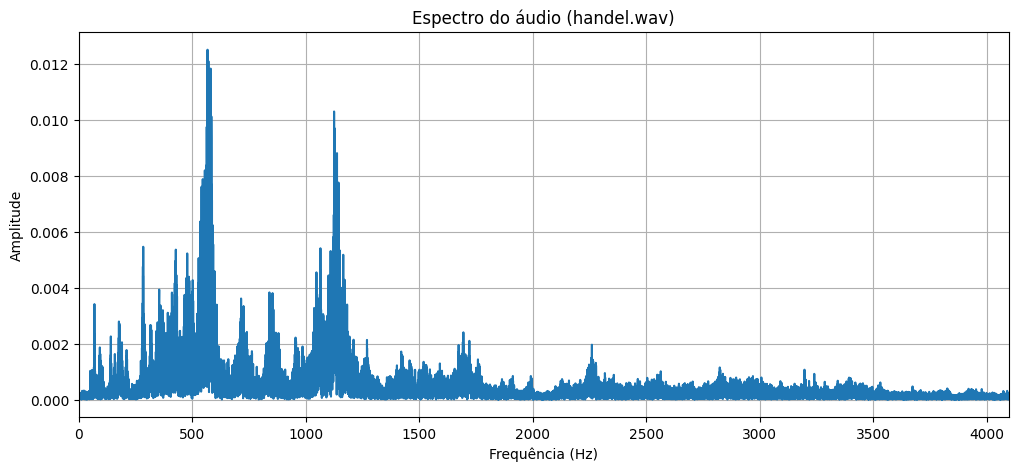

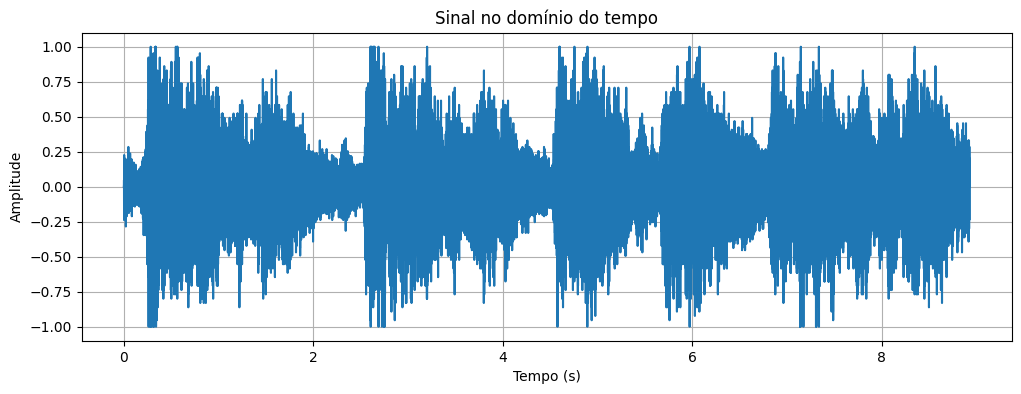

In [8]:
    frequencies, amplitudes = calculate_spectrum(audio_data, sample_rate, single_sided=True)

    plt.figure(figsize=(12, 5))
    plt.plot(frequencies, amplitudes)
    plt.title('Espectro do áudio (handel.wav)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, sample_rate/2)
    plt.grid(True)
    plt.show()

    t = np.linspace(0, len(audio_data)/sample_rate, len(audio_data))

    plt.figure(figsize=(12, 4))
    plt.plot(t, audio_data)
    plt.title('Sinal no domínio do tempo')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

In [ ]:
#B)
#O espectro do sinal de áudio apresenta uma distribuição contínua de energia ao longo das frequências, característica de sinais musicais reais. Observa-se maior concentração de energia nas baixas e médias frequências, além da presença de múltiplos picos associados a componentes harmônicas. Diferentemente de sinais senoidais puros, o áudio possui um espectro mais complexo e espalhado. Além disso, a FFT fornece uma visão global do espectro, não capturando variações temporais do sinal.

In [ ]:
#exercicio 4

In [9]:
#Função de subamostragem A)
def subsample(signal, M):
    return signal[::M]


In [10]:
#Aplicar para M = 2, 4, 8 B)
Ms = [2, 4, 8]

subsampled_signals = {}
new_sample_rates = {}

for M in Ms:
    y = subsample(audio_data, M)
    fs_new = sample_rate / M

    subsampled_signals[M] = y
    new_sample_rates[M] = fs_new

    print(f"M = {M} → nova fs = {fs_new} Hz")

M = 2 → nova fs = 4096.0 Hz
M = 4 → nova fs = 2048.0 Hz
M = 8 → nova fs = 1024.0 Hz


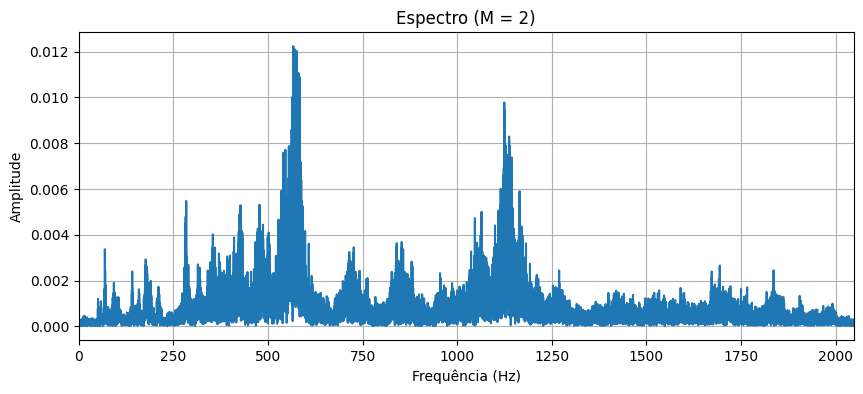

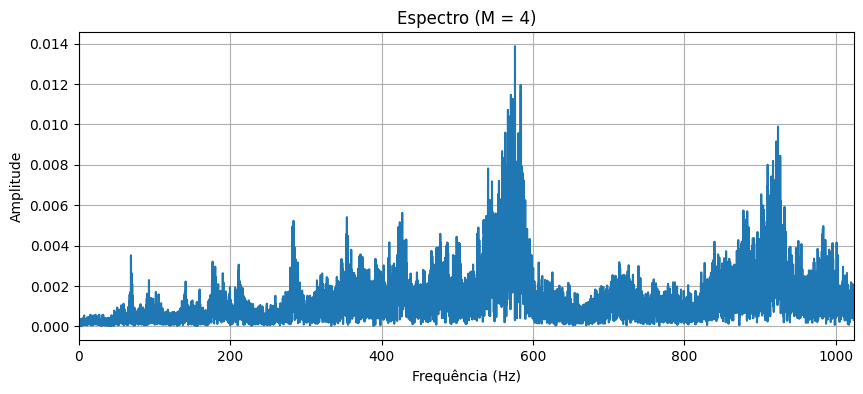

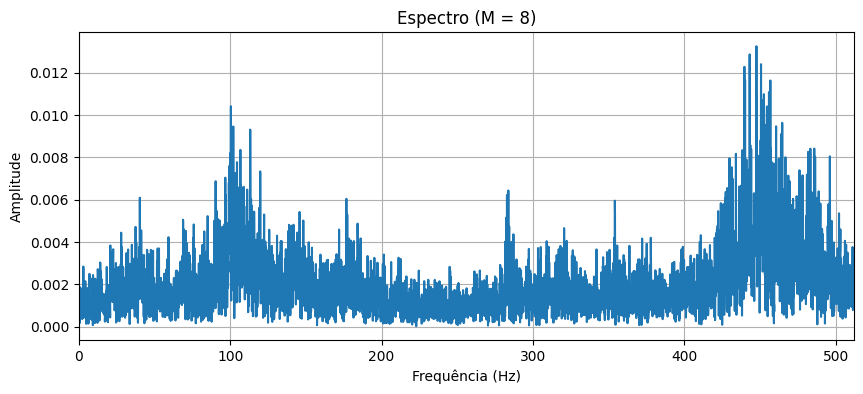

In [11]:
# Espectro dos sinais C)
for M in Ms:
    freq, amp = calculate_spectrum(subsampled_signals[M], new_sample_rates[M])

    plt.figure(figsize=(10, 4))
    plt.plot(freq, amp)
    plt.title(f'Espectro (M = {M})')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, new_sample_rates[M]/2)
    plt.grid(True)
    plt.show()

In [12]:
# Ouça os sinais D)
import IPython.display as ipd

for M in [2, 4, 8]:
    y = subsample(audio_data, M)

    print(f"\nÁudio M = {M}")
    display(ipd.Audio(y, rate=sample_rate))  # <-- aqui!


Áudio M = 2



Áudio M = 4



Áudio M = 8


In [ ]:
#Comentários E)
#A subamostragem reduz a taxa de amostragem do sinal, resultando em perda de informação espectral.

#Para valores pequenos de
#𝑀
#M, como 2, o sinal ainda mantém características próximas do original.

#À medida que
#𝑀
#M aumenta, ocorre aliasing devido à violação do critério de Nyquist, fazendo com que componentes de alta frequência sejam refletidos para frequências mais baixas.

#Isso é visível no espectro, onde há sobreposição de componentes espectrais.
#No domínio do áudio, isso se manifesta como distorção perceptível, tornando o som artificial ou degradado.
#Portanto, a subamostragem sem filtragem adequada pode comprometer significativamente a qualidade do sinal.

In [ ]:
#exercício 5

In [13]:
from scipy.signal import resample
Ms = [2, 4, 8]

results = {}

for M in Ms:
    # Método 1: subamostragem simples
    y_sub = audio_data[::M]

    # Método 2: resample (reduz número de pontos)
    new_length = len(audio_data) // M
    y_resamp = resample(audio_data, new_length)

    results[M] = {
        "sub": y_sub,
        "resamp": y_resamp
    }

In [14]:
import IPython.display as ipd

for M in Ms:
    print(f"\n===== M = {M} =====")

    print("Subamostrado:")
    display(ipd.Audio(results[M]["sub"], rate=sample_rate))

    print("Resample:")
    display(ipd.Audio(results[M]["resamp"], rate=sample_rate))


===== M = 2 =====
Subamostrado:


Resample:



===== M = 4 =====
Subamostrado:


Resample:



===== M = 8 =====
Subamostrado:


Resample:


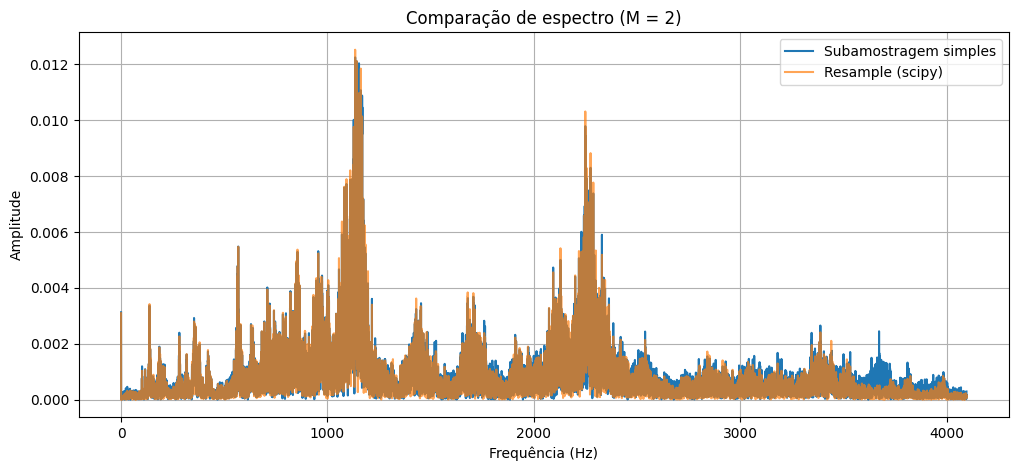

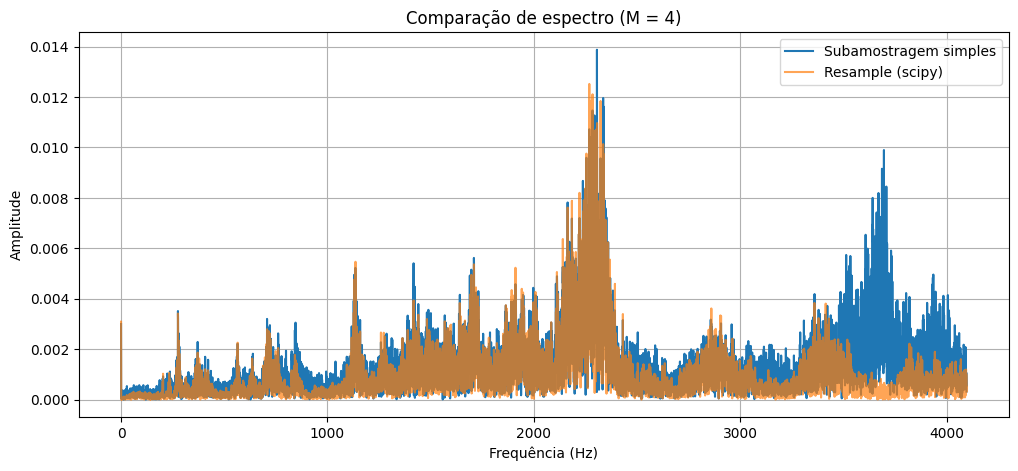

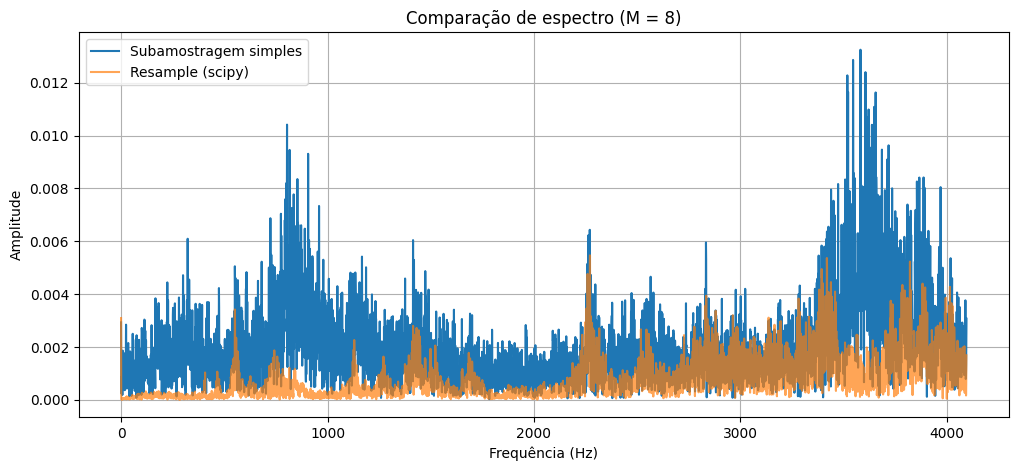

In [15]:
for M in Ms:
    plt.figure(figsize=(12, 5))

    # Subamostrado
    freq_sub, amp_sub = calculate_spectrum(results[M]["sub"], sample_rate)

    # Resample
    freq_res, amp_res = calculate_spectrum(results[M]["resamp"], sample_rate)

    plt.plot(freq_sub, amp_sub, label='Subamostragem simples')
    plt.plot(freq_res, amp_res, label='Resample (scipy)', alpha=0.7)

    plt.title(f'Comparação de espectro (M = {M})')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
#O método de resample atua implicitamente como um filtro passa-baixas, reduzindo componentes acima da nova frequência de Nyquist.

In [ ]:
#Exercício 6 (Fazer em aula)

In [ ]:
#Exercício 7 (Fazer em aula)

In [ ]:
#Exercício 8

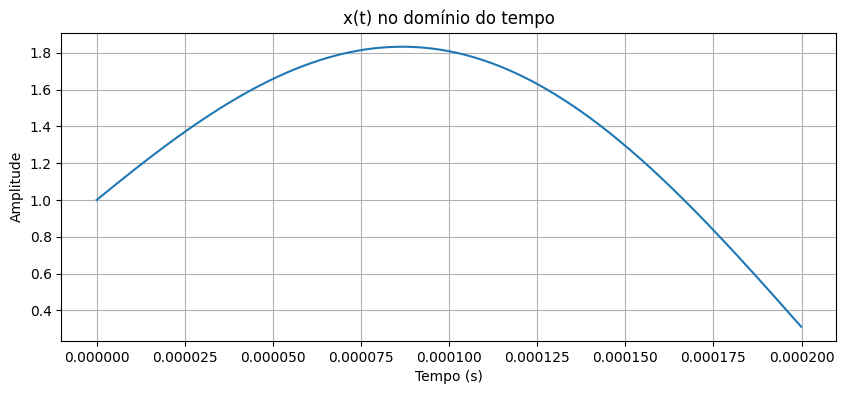

In [16]:
#A)
import numpy as np
import matplotlib.pyplot as plt

fs = 10_000_000  # 10 MHz
duration = 0.01  # 10 ms

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

x = np.cos(2000 * np.pi * t) + np.sin(5000 * np.pi * t)

plt.figure(figsize=(10,4))
plt.plot(t[:2000], x[:2000])  # zoom
plt.title('x(t) no domínio do tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

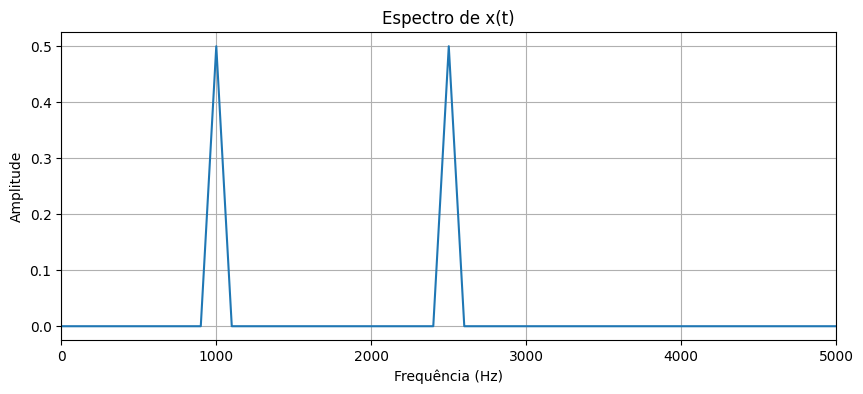

In [17]:
#B)
frequencies, amplitudes = calculate_spectrum(x, fs)

plt.figure(figsize=(10,4))
plt.plot(frequencies, amplitudes)
plt.xlim(0, 5000)
plt.title('Espectro de x(t)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [18]:
#C)
fs_nyquist = 5000

t_n = np.linspace(0, duration, int(fs_nyquist * duration), endpoint=False)

x_n = np.cos(2000 * np.pi * t_n) + np.sin(5000 * np.pi * t_n)

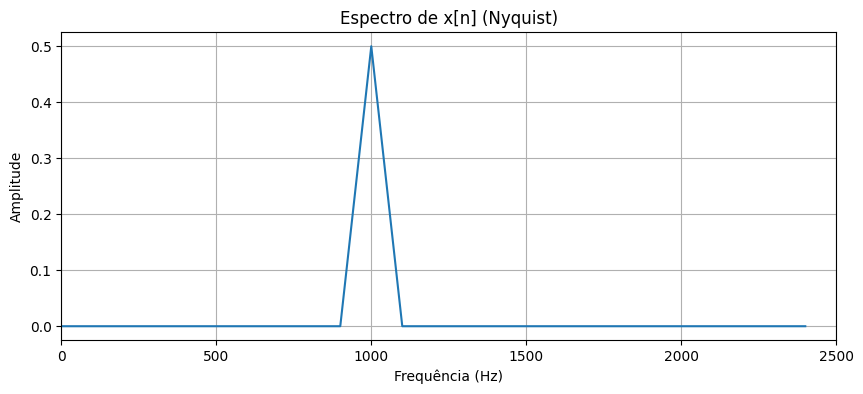

In [19]:
#D)
freq_n, amp_n = calculate_spectrum(x_n, fs_nyquist)

plt.figure(figsize=(10,4))
plt.plot(freq_n, amp_n)
plt.xlim(0, fs_nyquist/2)
plt.title('Espectro de x[n] (Nyquist)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [20]:
#E)
def sinc_reconstruction(xn, tn, t_cont):
    T = tn[1] - tn[0]
    xr = np.zeros_like(t_cont)

    for i in range(len(xn)):
        xr += xn[i] * np.sinc((t_cont - tn[i]) / T)

    return xr

x_rec = sinc_reconstruction(x_n, t_n, t)

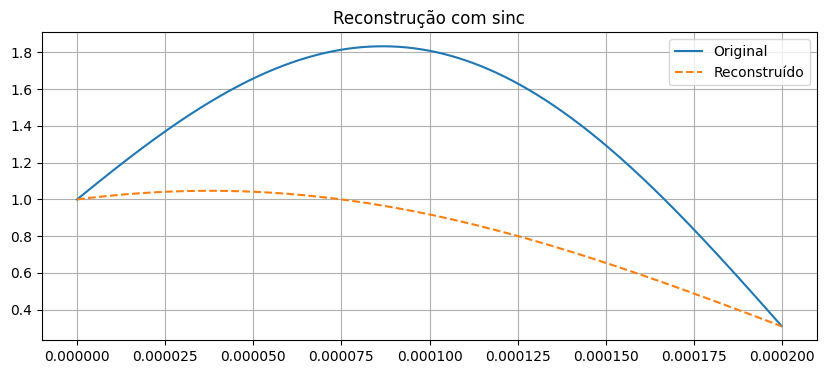

In [21]:
#Comparação
plt.figure(figsize=(10,4))
plt.plot(t[:2000], x[:2000], label='Original')
plt.plot(t[:2000], x_rec[:2000], '--', label='Reconstruído')
plt.legend()
plt.title('Reconstrução com sinc')
plt.grid()
plt.show()

In [ ]:
#F)
#O sinal original possui duas componentes espectrais em 1000 Hz e 2500 Hz.
#Ao amostrar com frequência muito alta (10 MHz), o sinal é representado de forma praticamente contínua.
#Ao utilizar a frequência de Nyquist (5000 Hz), o sinal ainda pode ser reconstruído, porém a componente de 2500 Hz encontra-se exatamente no limite, o que pode causar imprecisões. O espectro de x[n]
#x[n] mostra possíveis distorções na componente de maior frequência.
#A reconstrução utilizando interpolação sinc aproxima bem o sinal original, mas pode apresentar pequenas diferenças devido à limitação da taxa de amostragem.
#Isso demonstra que a amostragem na frequência de Nyquist é o limite teórico mínimo, sendo recomendável utilizar taxas maiores na prática.

In [ ]:
#Exercício 9

In [24]:
from google.colab import files
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

print("Faça upload do arquivo h_banheiro.wav:")
uploaded = files.upload()

print("Faça upload do arquivo sinal_taca.wav:")
uploaded = files.upload()

# nomes dos arquivos
file1 = 'h_banheiro.wav'
file2 = 'sinal_taca.wav'

fs1, audio1 = wavfile.read(file1)
fs2, audio2 = wavfile.read(file2)

print("h_banheiro:", fs1, audio1.shape)
print("sinal_taca:", fs2, audio2.shape)

Faça upload do arquivo h_banheiro.wav:


Saving h_banheiro.wav to h_banheiro (2).wav
Faça upload do arquivo sinal_taca.wav:


Saving sinal_taca.wav to sinal_taca (1).wav
h_banheiro: 22050 (9475,)
sinal_taca: 22050 (19100,)


In [28]:
def preprocess(audio):
    audio = audio.astype(np.float32)

    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)

    audio = audio / np.max(np.abs(audio))
    return audio

audio1 = preprocess(audio1)
audio2 = preprocess(audio2)

In [27]:
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency):
    N = len(signal)
    T = 1.0 / sampling_frequency

    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2]
    amplitudes = 1.0/N * np.abs(yf[:N//2])

    return xf, amplitudes

In [29]:
freq1, amp1 = calculate_spectrum(audio1, fs1)
freq2, amp2 = calculate_spectrum(audio2, fs2)

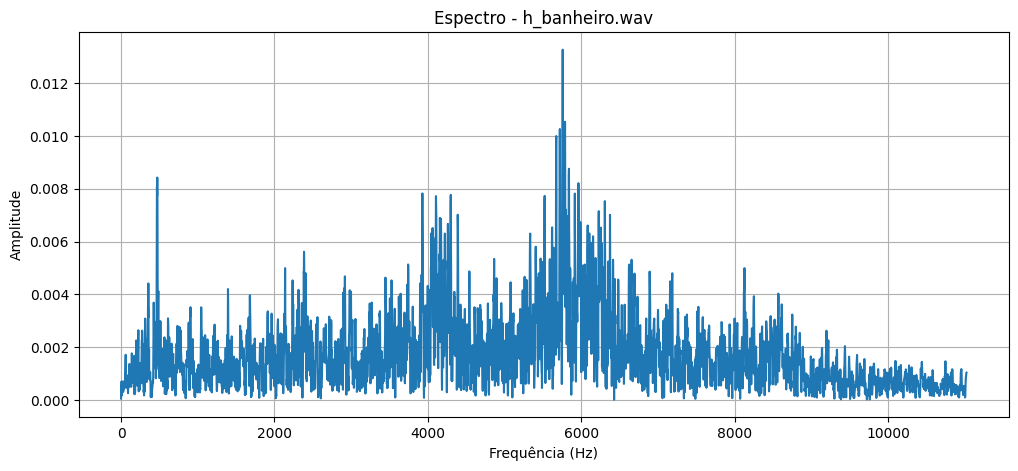

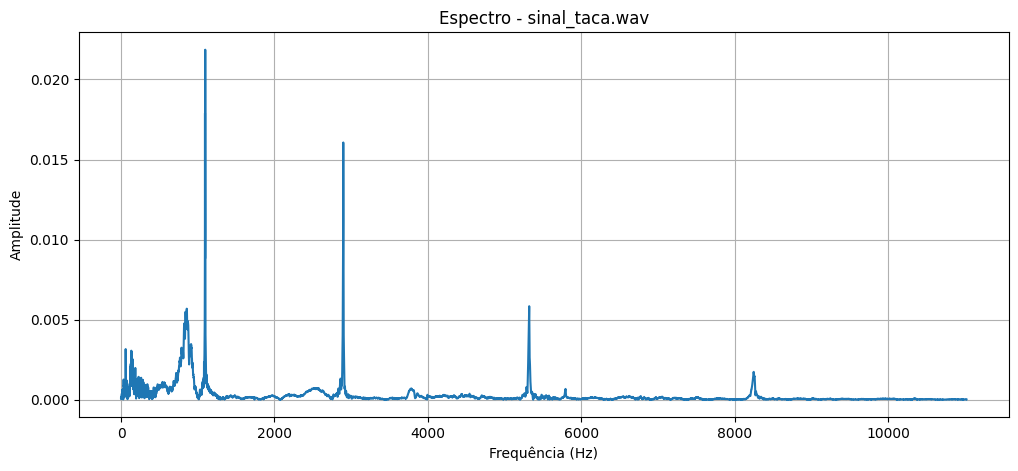

In [30]:
plt.figure(figsize=(12,5))
plt.plot(freq1, amp1)
plt.title('Espectro - h_banheiro.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


plt.figure(figsize=(12,5))
plt.plot(freq2, amp2)
plt.title('Espectro - sinal_taca.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [ ]:
#B)
#O sinal h_banheiro.wav apresenta um espectro mais distribuído ao longo das frequências, sem picos bem definidos, caracterizando um sinal semelhante a ruído ou som ambiente com múltiplas componentes espectrais.
#Já o sinal sinal_taca.wav apresenta picos bem definidos no espectro, indicando a presença de frequências dominantes associadas à vibração da taça.
#Isso ocorre porque o som da taça é gerado por ressonância mecânica, resultando em componentes harmônicas específicas.
#Em contraste, o som do banheiro possui características mais aleatórias e difusas, refletindo múltiplas fontes sonoras e reflexões.
#Portanto, os espectros evidenciam claramente a diferença entre um sinal harmônico e um sinal mais ruidoso.

In [ ]:
#10)